In [1]:
import pandas as pd
import math
import random
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl
from openpyxl.styles import PatternFill
import squarify
import stemgraphic
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as stats
import mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth

In [5]:
data = pd.read_csv(r"D:\project\Drugs-Side-Effects-and-Medical-Conditions-Analysis-main\Drugs-Side-Effects-and-Medical-Conditions-Analysis-main\drugs_side_effects_drugs_com.csv")
data


,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,3,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0,https://www.drugs.com/mtm/benzphetamine.html,https://www.drugs.com/condition/obesity.html
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,4,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/mtm/fenfluramine.html,https://www.drugs.com/condition/obesity.html
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,3,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/pro/fendique-er.html,https://www.drugs.com/condition/obesity.html
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,NaN,N,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN,https://www.drugs.com/imcivree.html,https://www.drugs.com/condition/obesity.html


In [9]:
import pandas as pd

# Read the CSV file
data = pd.read_csv(r'D:\project\Drugs-Side-Effects-and-Medical-Conditions-Analysis-main\Drugs-Side-Effects-and-Medical-Conditions-Analysis-main\drugs_side_effects_drugs_com.csv')  # Use correct file path

# Print the first few rows to inspect
print(data.head())

# Print column names to ensure all columns are present
print(data.columns.tolist())

        drug_name medical_condition  \
0     doxycycline              Acne   
1  spironolactone              Acne   
2     minocycline              Acne   
3        Accutane              Acne   
4     clindamycin              Acne   

                                        side_effects         generic_name  \
0  (hives, difficult breathing, swelling in your ...          doxycycline   
1  hives ; difficulty breathing; swelling of your...       spironolactone   
2  skin rash, fever, swollen glands, flu-like sym...          minocycline   
3  problems with your vision or hearing; muscle o...  isotretinoin (oral)   
4  hives ; difficult breathing; swelling of your ...  clindamycin topical   

                                        drug_classes  \
0         Miscellaneous antimalarials, Tetracyclines   
1  Aldosterone receptor antagonists, Potassium-sp...   
2                                      Tetracyclines   
3  Miscellaneous antineoplastics, Miscellaneous u...   
4       Topical acne a

In [11]:
print(f"Num of attributes: {data.shape[1]}")
print(f"Num of rows of data: {data.shape[0]}")

Num of attributes: 17
Num of rows of data: 2931


In [13]:
data = data.drop(['csa', 'drug_link', 'medical_condition_url'], axis=1)
data

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,NaN,NaN,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


In [15]:
columns_to_be_modified = ['pregnancy_category', 'alcohol']

# Every other attributes with null values is indication that the data is not available

for i in data.index:
    for j in columns_to_be_modified:
        check_ = data[j].isnull()
        if check_[i] == True:
            data.loc[i, j] = 0
            
data

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


In [17]:
print(data.columns.tolist())

['drug_name', 'medical_condition', 'side_effects', 'generic_name', 'drug_classes', 'brand_names', 'activity', 'rx_otc', 'pregnancy_category', 'alcohol', 'related_drugs', 'medical_condition_description', 'rating', 'no_of_reviews']


In [19]:
data1 = data
data_1 = data1.dropna(axis=0)
data_1

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
5,Aldactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...",CaroSpir,35%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.6,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,phendimetrazine,Weight Loss,hives ; difficult breathing; swelling of your ...,phendimetrazine,"Anorexiants, CNS stimulants",Melfiat,14%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,8.3,150.0
2918,Pregnyl,Weight Loss,hives ; difficult breathing; swelling of your ...,human chorionic gonadotropin (HCG) (injectable),Gonadotropins,"Novarel, Ovidrel",6%,Rx,X,0,testosterone: https://www.drugs.com/testostero...,Weight Loss (Obesity/Overweight) More than hal...,9.0,1.0
2923,chorionic gonadotropin (hcg),Weight Loss,hives ; difficult breathing; swelling of your ...,human chorionic gonadotropin (HCG) (injectable),Gonadotropins,"Novarel, Ovidrel, Pregnyl, Profasi, Chorex, Go...",3%,Rx,X,0,testosterone: https://www.drugs.com/testostero...,Weight Loss (Obesity/Overweight) More than hal...,7.0,14.0
2924,Lomaira,Weight Loss,hives ; difficult breathing; swelling of your ...,phentermine,Anorexiants,"Adipex-P, Suprenza",3%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.6,40.0


In [21]:
unique_medical_conditions = list(data.medical_condition.unique())
unique_drugs = list(data.drug_name.unique())

In [23]:
import re
import string
import pandas as pd

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def simple_tokenize(document):
    if pd.isnull(document):
        return []
    document = str(document).lower()
    # Split words and remove punctuation
    words = re.findall(r'\b\w+\b', document)
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    return words

side_effects = [
    list(set(simple_tokenize(text))) for text in data['side_effects']
]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
related_drugs = []
for i in data.index:
    strings = []
    string = ""
    for aa in range(len(str(data["related_drugs"][i]))):
        if str(data["related_drugs"][i])[aa] == ":":
            strings.append(string)
            string = ""
            break
        else:
            string += str(data["related_drugs"][i])[aa]
    string = ""
    for j in range(len(str(data["related_drugs"][i]))):
        if str(data["related_drugs"][i])[j] == "|":
            for k in range(j+2, len(str(data["related_drugs"][i]))):
                if str(data["related_drugs"][i][k]) == ":":
                    strings.append(string)
                    string = ""
                    break
                else:
                    string += str(data["related_drugs"][i][k])
            j = k
    related_drugs.append(strings)   

In [27]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords

# Download necessary data
nltk.download('stopwords')

# Setup stopwords
stop_words = set(stopwords.words('english'))

# Define simple tokenizer
def simple_tokenize(document):
    if pd.isnull(document):
        return []
    document = str(document).lower()
    words = re.findall(r'\b\w+\b', document)
    words = [word for word in words if word not in stop_words]
    return words

# --- Main logic ---

# Get medical_condition_descriptions for each unique_medical_condition
medical_condition_descriptions = []

for condition in unique_medical_conditions:
    matched_rows = data[data['medical_condition'] == condition]  # 
    if not matched_rows.empty:
        medical_condition_descriptions.append(matched_rows.iloc[0]['medical_condition_description'])
    else:
        medical_condition_descriptions.append(None)  # If no match found

# Tokenize the medical_condition_descriptions
tokenized_medical_condition_descriptions = [
    list(set(simple_tokenize(desc))) for desc in medical_condition_descriptions
]

# Final tokenized descriptions are stored here


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
def load_data():
    data = pd.read_csv(r"D:\project\Drugs-Side-Effects-and-Medical-Conditions-Analysis-main\Drugs-Side-Effects-and-Medical-Conditions-Analysis-main\drugs_side_effects_drugs_com.csv")
    data = data.drop(['csa', 'drug_link', 'medical_condition_url'], axis=1)
    columns_to_be_modified = ['pregnancy_category', 'alcohol']
    # Every other attributes with null values is indication that the data is not available
    for i in data.index:
        for j in columns_to_be_modified:
            check_ = data[j].isnull()
            if check_[i] == True:
                data.loc[i, j] = 0
    return data

data = load_data()
for i in side_effects:
    i = set(i)
    i = list(i)

sample = 0
print("SAMPLE TOKENIZED DATA\n")
print(f"Drug_name: {data['drug_name'][sample]}\n\nMedical Condition: {data['medical_condition'][sample]}\n\nSide Effects: {side_effects[sample]}\n\nRelated Drugs: {related_drugs[sample]}\n\n Medical Condition Descriptions: {tokenized_medical_condition_descriptions[sample]}")

SAMPLE TOKENIZED DATA

Drug_name: doxycycline

Medical Condition: Acne

Side Effects: ['bleeding', 'rash', 'muscle', 'loss', 'may', 'side', 'body', 'irregular', 'peeling', 'urine', 'using', 'cell', 'chills', 'little', 'easy', 'darkened', 'include', 'throat', 'like', 'rhythm', 'weeks', 'sore', 'chest', 'fast', 'low', 'flu', 'aches', 'jaundice', 'blistering', 'face', 'tiredness', 'glands', 'mild', 'dizziness', 'diarrhea', 'cause', 'eyes', 'white', 'began', 'unusual', 'ears', 'symptoms', 'color', 'nausea', 'drug', 'parts', 'difficult', 'upper', 'seek', 'hives', 'common', 'feeling', 'purple', 'affect', 'breathing', 'yellowing', 'upset', 'swelling', 'many', 'appetite', 'doctor', 'discharge', 'urination', 'stomach', 'effects', 'swallowing', 'occur', 'watery', 'irritation', 'skin', 'problems', 'ringing', 'several', 'dark', 'heart', 'treatment', 'vision', 'medical', 'headaches', 'trouble', 'pale', 'swollen', 'causes', 'short', 'blood', 'pain', 'fever', 'burning', 'vaginal', 'bruising', 'spread

In [33]:
print("After data preprocessing, data is as follows:")
data

After data preprocessing, data is as follows:


,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,0,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,0,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,benzphetamine,Weight Loss,hives ; difficulty breathing; swelling of your...,benzphetamine,"Anorexiants, CNS stimulants","Didrex, Regimex",2%,Rx,X,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,7.5,17.0
2927,fenfluramine,Weight Loss,hives ; difficult breathing; swelling of your ...,fenfluramine,"Anorexiants, CNS stimulants, Miscellaneous ant...",Fintepla,1%,Rx,C,X,NaN,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2928,Fendique ER,Weight Loss,NaN,phendimetrazine tartrate,"Anorexiants, CNS stimulants",NaN,0%,Rx,C,X,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN
2929,Imcivree,Weight Loss,"Imcivree may cause serious side effects, inclu...",setmelanotide,Melanocortin receptor agonists,NaN,0%,Rx,0,0,phentermine: https://www.drugs.com/phentermine...,Weight Loss (Obesity/Overweight) More than hal...,NaN,NaN


In [35]:
print(f"Dimension of the dataset: {data.shape}\n")
cnt = 0
for i in data.columns:
    print(f"Mode in column {data.columns[cnt]}: {statistics.mode(data[data.columns[cnt]])}")
    cnt += 1
print("\n")

print(f"Data types of each column:\n{data.dtypes}\n")

Dimension of the dataset: (2931, 14)

Mode in column drug_name: triamcinolone
Mode in column medical_condition: Pain
Mode in column side_effects: nan
Mode in column generic_name: nan
Mode in column drug_classes: Upper respiratory combinations
Mode in column brand_names: nan
Mode in column activity: 0%
Mode in column rx_otc: Rx
Mode in column pregnancy_category: C
Mode in column alcohol: 0
Mode in column related_drugs: nan
Mode in column medical_condition_description: Pain An unpleasant sensory and emotional experience associated with actual or potential tissue damage or described in terms of such damage.
Mode in column rating: 10.0
Mode in column no_of_reviews: 1.0


Data types of each column:
drug_name                         object
medical_condition                 object
side_effects                      object
generic_name                      object
drug_classes                      object
brand_names                       object
activity                          object
rx_otc    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2931 non-null   object 
 9   alcohol                        2931 non-null   object 
 10  related_drugs                  1462 non-null   object 
 11  medical_condition_description  2931 non-null   object 
 12  rating                         1586 non-null   f

drug_name                           0
medical_condition                   0
side_effects                      124
generic_name                       43
drug_classes                       82
brand_names                      1213
activity                            0
rx_otc                              1
pregnancy_category                  0
alcohol                             0
related_drugs                    1469
medical_condition_description       0
rating                           1345
no_of_reviews                    1345
dtype: int64

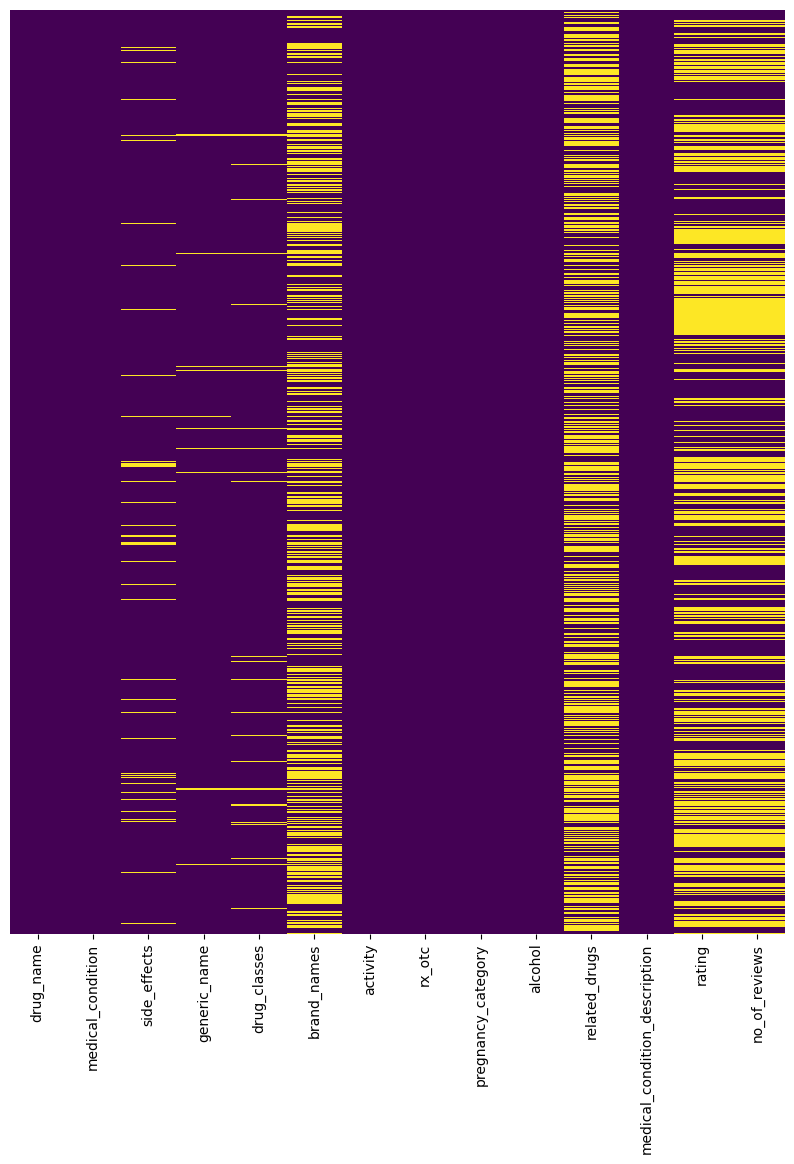

In [37]:
df =data
df.info()
# calculate duplicates
dups = df.duplicated()
# report if there are any duplicates
print(df.any())
# list all duplicate rows

print("Duplicate Rows",df[dups])
#Cardinality 
df.nunique() # To determine the maximum and minimum number of variations in each column of the dataset
#Lets now check for null fields
import seaborn as sns
plt.figure(figsize=(10,12))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
df.isnull().sum()

In [39]:
unique_medical_conditions = list(data.medical_condition.unique())
unique_drugs = list(data.drug_name.unique())

print(f"List of unique Medical Conditions being discussed are:\n{unique_medical_conditions}\n\n")
print(f"List of unique drugs being discussed are:\n{unique_drugs}\n\n")

print(f"Number of unique drugs: {len(unique_drugs)}")
print(f"Total data rows: {data.shape[0]}")

List of unique Medical Conditions being discussed are:
['Acne', 'ADHD', 'AIDS/HIV', 'Allergies', "Alzheimer's", 'Angina', 'Anxiety', 'Asthma', 'Bipolar Disorder', 'Bronchitis', 'Cancer', 'Cholesterol', 'Colds & Flu', 'Constipation', 'COPD', 'Covid 19', 'Depression', 'Diabetes (Type 1)', 'Diabetes (Type 2)', 'Diarrhea', 'Eczema', 'Erectile Dysfunction', 'Gastrointestinal', 'GERD (Heartburn)', 'Gout', 'Hair Loss', 'Hayfever', 'Herpes', 'Hypertension', 'Hypothyroidism', 'IBD (Bowel)', 'Incontinence', 'Insomnia', 'Menopause', 'Migraine', 'Osteoarthritis', 'Osteoporosis', 'Pain', 'Pneumonia', 'Psoriasis', 'Rheumatoid Arthritis', 'Schizophrenia', 'Seizures', 'Stroke', 'Swine Flu', 'UTI', 'Weight Loss']


List of unique drugs being discussed are:
['doxycycline', 'spironolactone', 'minocycline', 'Accutane', 'clindamycin', 'Aldactone', 'tretinoin', 'isotretinoin', 'Bactrim', 'Retin-A', 'Aczone', 'benzoyl peroxide', 'Differin', 'Epiduo', 'adapalene', 'cephalexin', 'Doryx', 'tetracycline', 'Septr

In [41]:
drugs_multiple_condns = []
drugs_so_far = []

for i in data.index:
    if data["drug_name"][i] in drugs_so_far and data["drug_name"][i] not in drugs_multiple_condns:
        drugs_multiple_condns.append(data["drug_name"][i])
    if data["drug_name"][i] not in drugs_so_far:
        drugs_so_far.append(data["drug_name"][i])

print("The below is the list of only drugs that have multi-purpose:")
for i in drugs_multiple_condns:
    print(i)

The below is the list of only drugs that have multi-purpose:
minocycline
erythromycin
triamcinolone
fluocinolone
doxepin
fluticasone
mometasone
beclomethasone
ciclesonide
acyclovir
minoxidil
budesonide
hydrocortisone
cromolyn
diclofenac
diphenhydramine
clindamycin
betamethasone


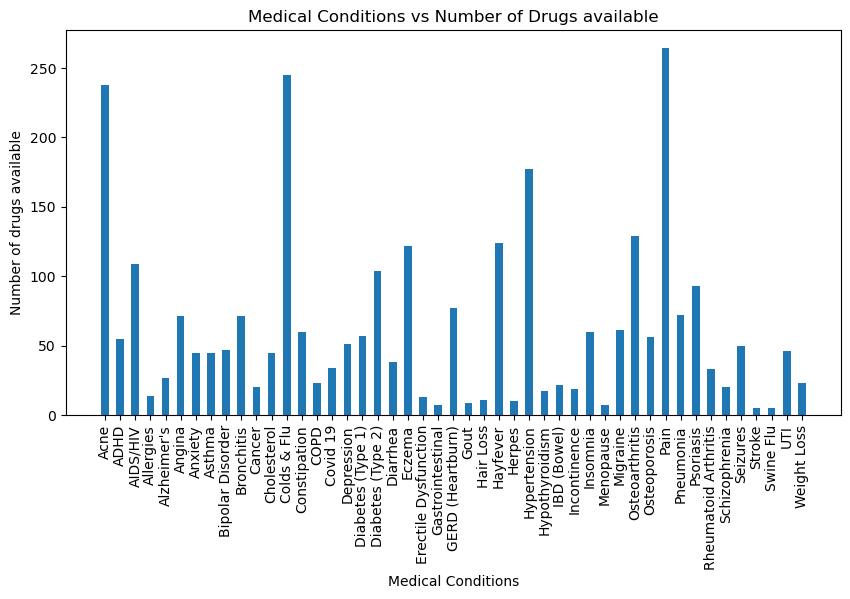

In [43]:
available_drugs_for_condns = [0]*len(unique_medical_conditions)

for i in data.index:
    medical_condition = str(data['medical_condition'][i])
    indexx = unique_medical_conditions.index(medical_condition)
    available_drugs_for_condns[indexx] += 1

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(unique_medical_conditions, available_drugs_for_condns, width = 0.5)
plt.xlabel("Medical Conditions")
plt.ylabel(f"Number of drugs available")
plt.title(f"Medical Conditions vs Number of Drugs available")
plt.xticks(rotation=90)
plt.show()

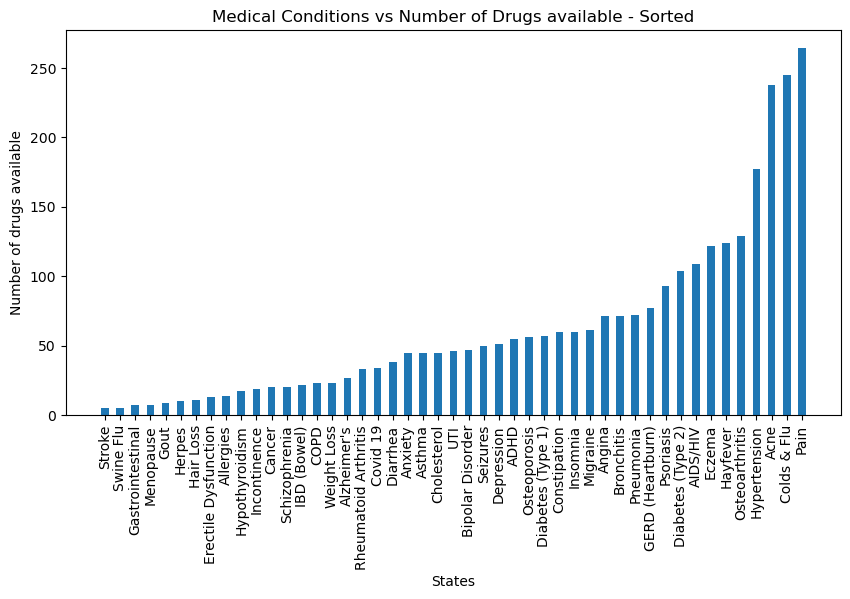

In [45]:
available_drugs_for_condns, unique_medical_conditions = zip(*sorted(zip(available_drugs_for_condns, unique_medical_conditions)))

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(unique_medical_conditions, available_drugs_for_condns, width = 0.5)
plt.xlabel("States")
plt.ylabel(f"Number of drugs available")
plt.title(f"Medical Conditions vs Number of Drugs available - Sorted")
plt.xticks(rotation=90)
plt.show()

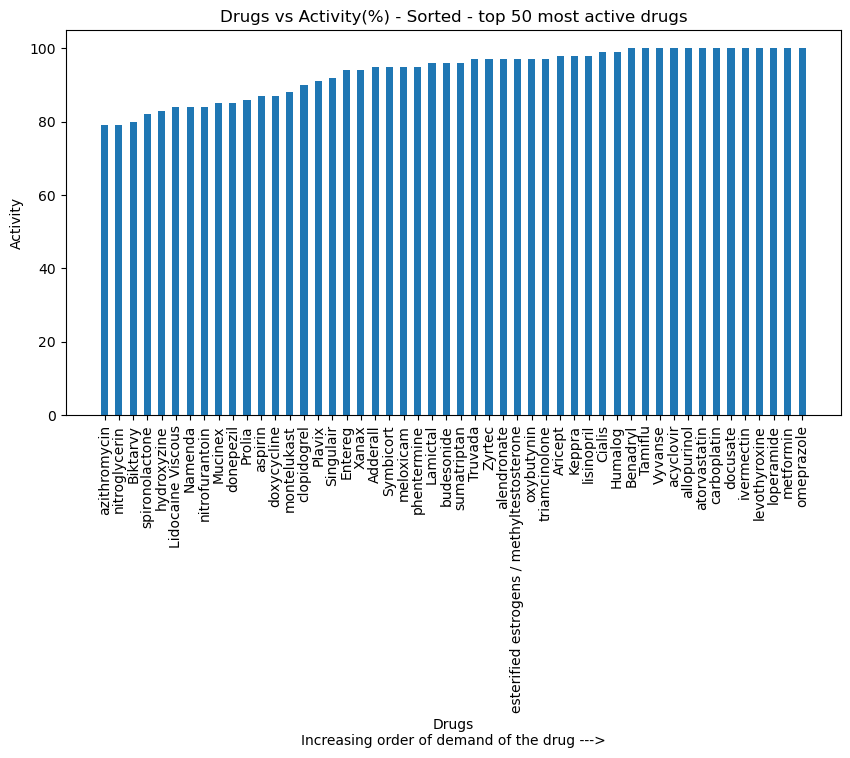

In [47]:
activities = []
drugs = []
for i in data.index:
    activities.append(int(data["activity"][i][:-1]))
    drugs.append(str(data["drug_name"][i]))


# Pareto Chart
activities, drugs = zip(*sorted(zip(activities, drugs)))

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(drugs[-50:], activities[-50:], width = 0.5)
plt.xlabel("Drugs\nIncreasing order of demand of the drug --->")
plt.ylabel(f"Activity")
plt.title(f"Drugs vs Activity(%) - Sorted - top 50 most active drugs")
plt.xticks(rotation=90)
plt.show()

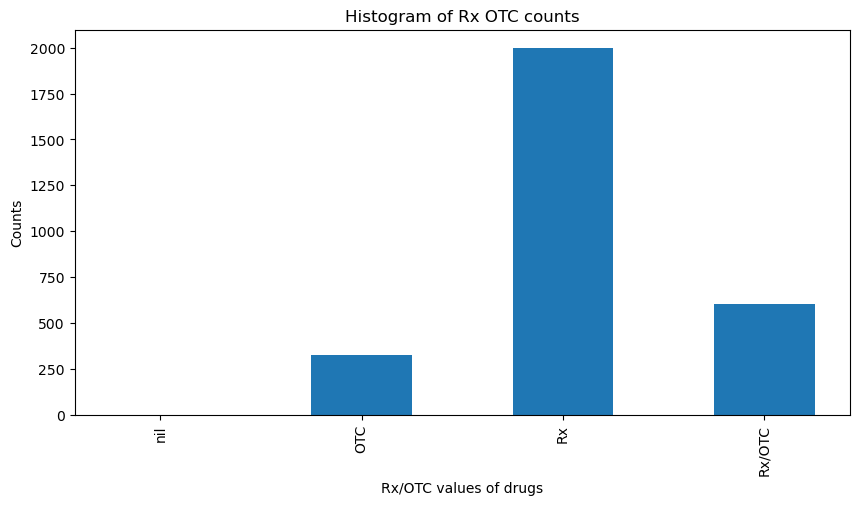

In [49]:
unique_rx_otc = ['nil', 'OTC', 'Rx', 'Rx/OTC']

cnts_rtx_otc = [0]*len(unique_rx_otc)
for i in data.index:
    if data["rx_otc"][i] == None:
        cnts_rtx_otc[0] += 1
    elif data["rx_otc"][i] == 'OTC':
        cnts_rtx_otc[1] += 1
    elif data["rx_otc"][i] == 'Rx':
        cnts_rtx_otc[2] += 1
    elif data["rx_otc"][i] == 'Rx/OTC':
        cnts_rtx_otc[3] += 1
        
# Pareto Chart
# cnts, unique_rx_otc = zip(*sorted(zip(cnts, unique_rx_otc)))

#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(unique_rx_otc, cnts_rtx_otc, width = 0.5)
plt.xlabel("Rx/OTC values of drugs")
plt.ylabel(f"Counts")
plt.title(f"Histogram of Rx OTC counts")
plt.xticks(rotation=90)
plt.show()

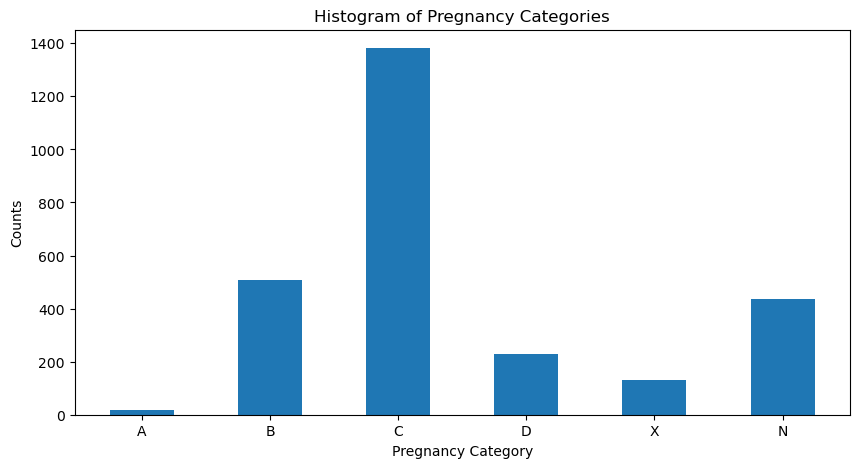

In [51]:
pregnancy_categories = ['A', 'B', 'C', 'D', 'X', 'N']

cnts_preg_cat = [0]*len(pregnancy_categories)
for i in data.index:
    if data["pregnancy_category"][i] == 'A':
        cnts_preg_cat[0] += 1
    elif data["pregnancy_category"][i] == 'B':
        cnts_preg_cat[1] += 1
    elif data["pregnancy_category"][i] == 'C':
        cnts_preg_cat[2] += 1
    elif data["pregnancy_category"][i] == 'D':
        cnts_preg_cat[3] += 1
    elif data["pregnancy_category"][i] == 'X':
        cnts_preg_cat[4] += 1
    elif data["pregnancy_category"][i] == 'N':
        cnts_preg_cat[5] += 1
    
        
# Pareto Chart
#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(pregnancy_categories, cnts_preg_cat, width = 0.5)
plt.xlabel("Pregnancy Category")
plt.ylabel(f"Counts")
plt.title(f"Histogram of Pregnancy Categories")
plt.xticks(rotation=0)
plt.show()

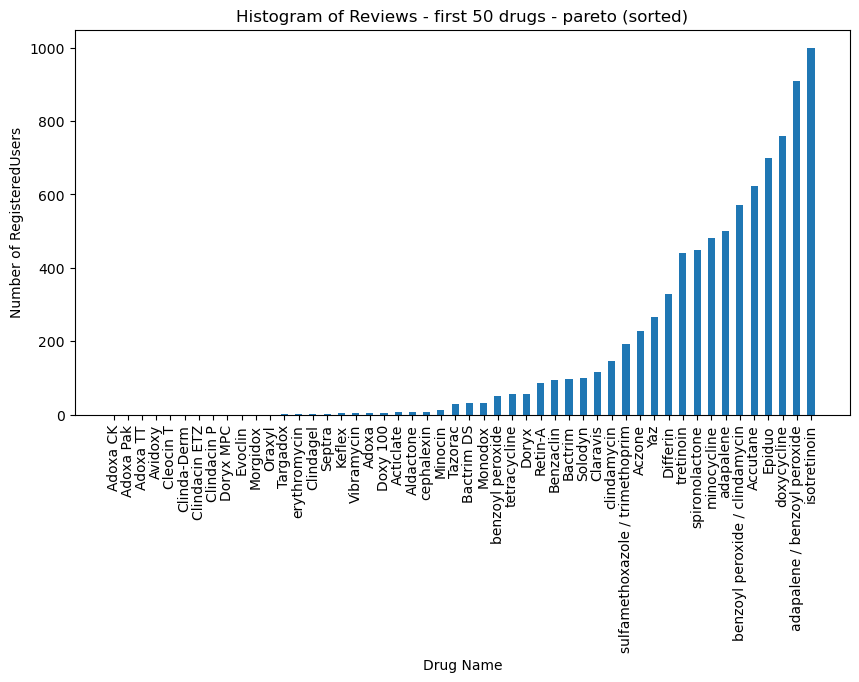

In [53]:
drug_names = []
no_of_ratings = []

num = 50

cnt = 0
for i in data.index:
    if cnt != num:
        drug_names.append(data["drug_name"][i])
        if not np.isnan(data["no_of_reviews"][i]):
            no_of_ratings.append(int(data["no_of_reviews"][i]))
        else:
            no_of_ratings.append(0)
    else:
        break
    cnt += 1

#Bar Graph
fig = plt.figure(figsize = (10, 5))
no_of_ratings, drug_names = zip(*sorted(zip(no_of_ratings, drug_names)))
# creating the bar plot
# num = 10
plt.bar(drug_names, no_of_ratings, width = 0.5)
plt.xlabel("Drug Name")
plt.ylabel(f"Number of RegisteredUsers")
plt.title(f"Histogram of Reviews - first {num} drugs - pareto (sorted)")
plt.xticks(rotation=90)
plt.show()

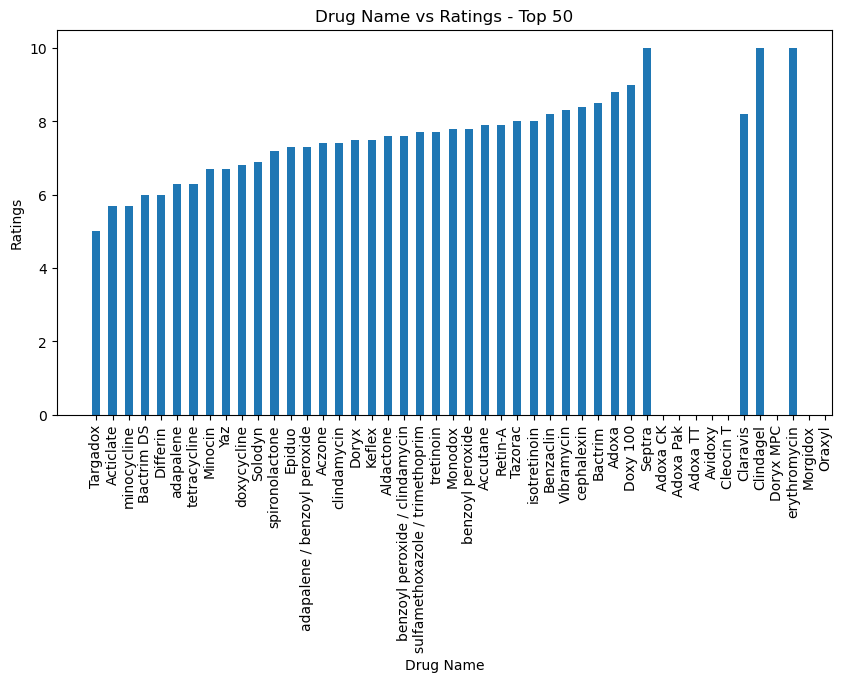

In [55]:
num = 50
drug_names = data["drug_name"][:num]
ratings = data["rating"][:num]
ratings, drug_names = zip(*sorted(zip(ratings, drug_names)))        
# Pareto Chart
#Bar Graph
fig = plt.figure(figsize = (10, 5))
# creating the bar plot
plt.bar(drug_names, ratings, width = 0.5)
plt.xlabel("Drug Name")
plt.ylabel(f"Ratings")
plt.title(f"Drug Name vs Ratings - Top {num}")
plt.xticks(rotation=90)
plt.show()

C:\Users\sanni\AppData\Local\Temp\ipykernel_1992\3985345823.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='rating', ylabel='count'>

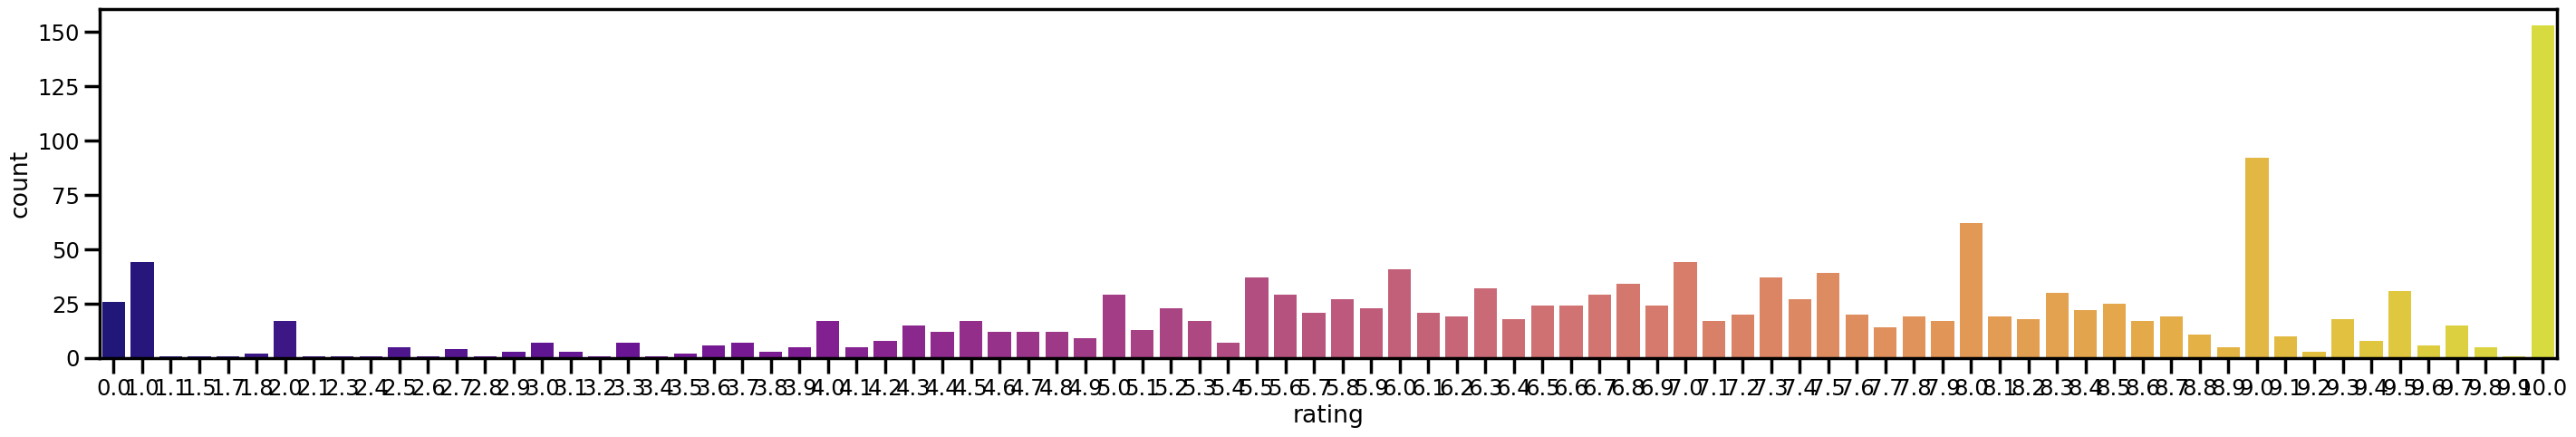

In [57]:
sns.set_context('poster', font_scale=0.8)
plt.figure(figsize=(35,5))
sns.countplot(data=data,x = 'rating',palette='plasma')

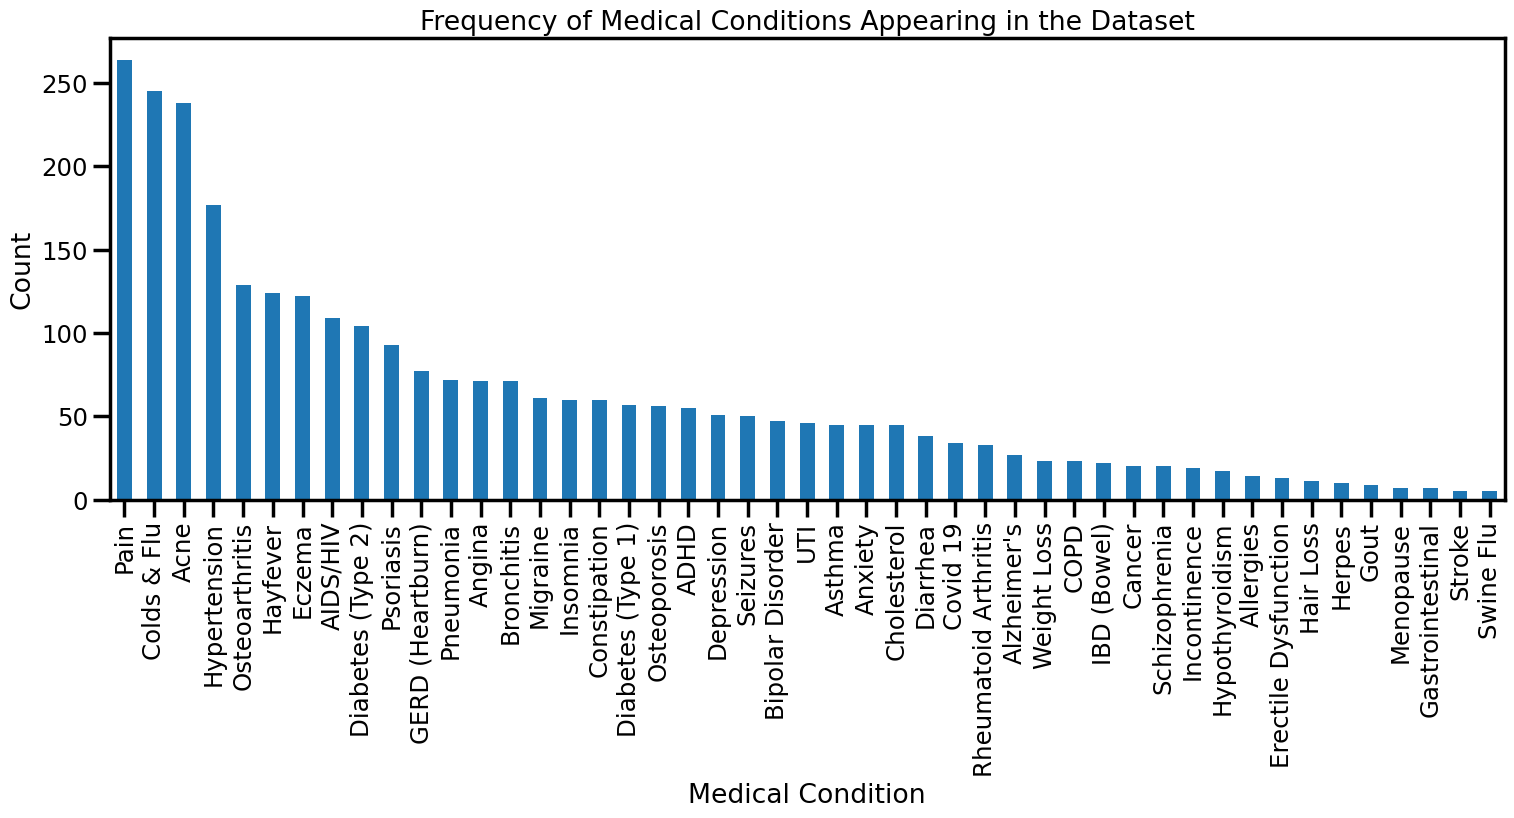

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the context for the plot
sns.set_context('poster', font_scale=0.8)

# Count the occurrences of each medical condition
condition_counts = data['medical_condition'].value_counts()

# Create a bar plot of the counts
condition_counts.plot(kind='bar', figsize=(18, 6))

# Customize the plot
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Frequency of Medical Conditions Appearing in the Dataset')

# Display the plot
plt.show()

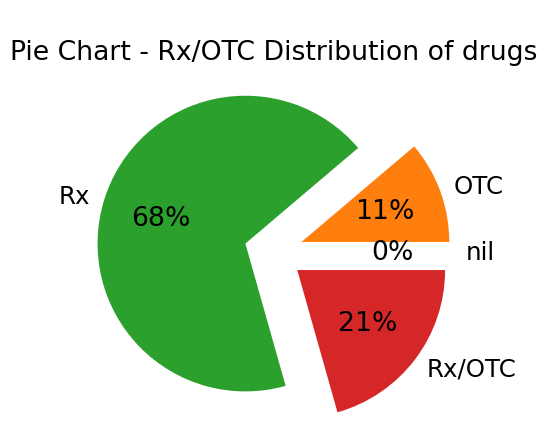

In [61]:

y = np.array(cnts_rtx_otc)
mylabels = unique_rx_otc
myexplode = [0.2]*len(unique_rx_otc)
plt.title("\nPie Chart - Rx/OTC Distribution of drugs")
plt.pie(y, labels = mylabels, explode = myexplode, autopct='%.0f%%')
plt.show() 

pregnancy_category
C    1382
B     509
N     436
0     229
D     228
X     129
A      18
Name: count, dtype: int64

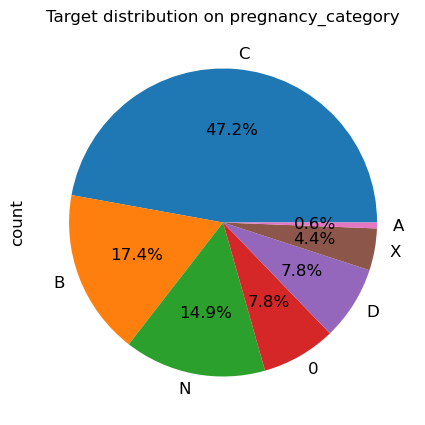

In [63]:
sns.set_context('poster', font_scale=0.5)
plt.figure(figsize=(5,5))
# Pie plot
data['pregnancy_category'].value_counts().plot.pie(autopct='%1.1f%%', textprops={'fontsize':12}).set_title("Target distribution on pregnancy_category")
data['pregnancy_category'].value_counts()

medical_condition
Pain                    264
Colds & Flu             245
Acne                    238
Hypertension            177
Osteoarthritis          129
Hayfever                124
Eczema                  122
AIDS/HIV                109
Diabetes (Type 2)       104
Psoriasis                93
GERD (Heartburn)         77
Pneumonia                72
Angina                   71
Bronchitis               71
Migraine                 61
Insomnia                 60
Constipation             60
Diabetes (Type 1)        57
Osteoporosis             56
ADHD                     55
Depression               51
Seizures                 50
Bipolar Disorder         47
UTI                      46
Asthma                   45
Anxiety                  45
Cholesterol              45
Diarrhea                 38
Covid 19                 34
Rheumatoid Arthritis     33
Alzheimer's              27
Weight Loss              23
COPD                     23
IBD (Bowel)              22
Cancer                   20
Sc

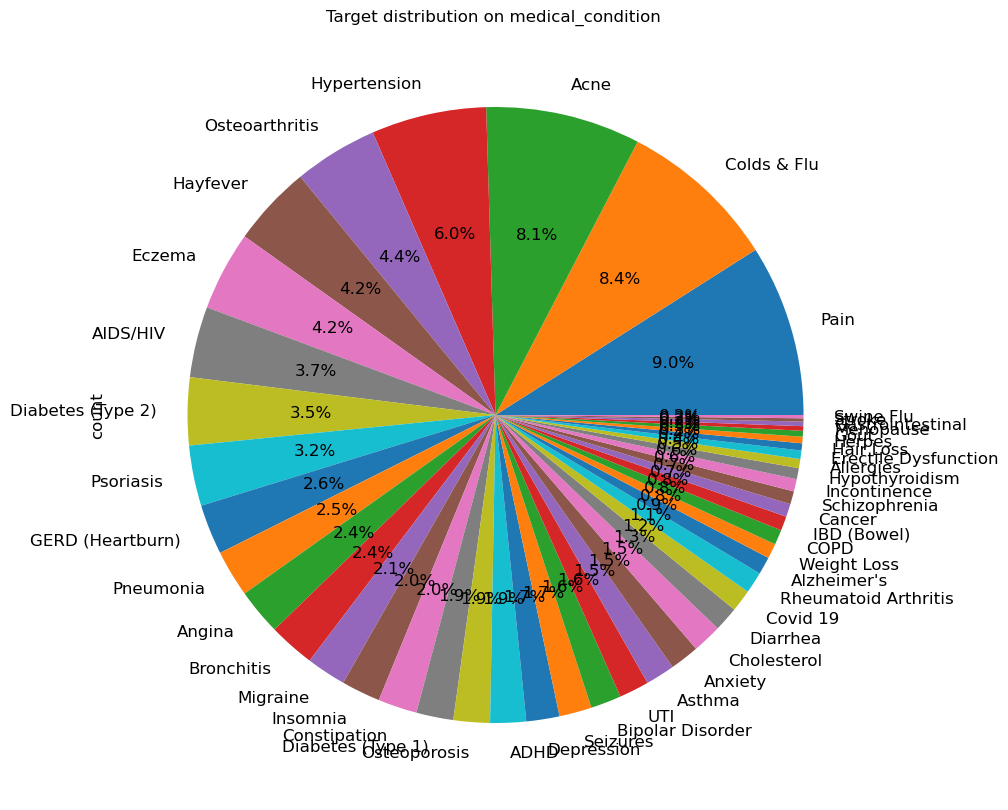

In [65]:

sns.set_context('poster', font_scale=0.5)
plt.figure(figsize=(10,10))
# Pie plot
data['medical_condition'].value_counts().plot.pie(autopct='%1.1f%%', textprops={'fontsize':12}).set_title("Target distribution on medical_condition ")
data['medical_condition'].value_counts()

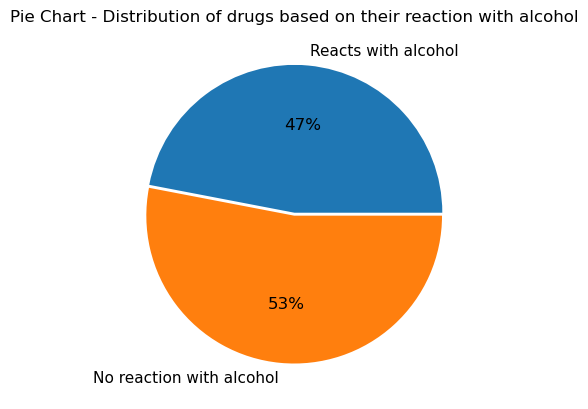

In [67]:
# Alcohol
cnts = 0

for i in data.index:
    if data["alcohol"][i] == 'X':
        cnts += 1
cnts_alcohol = [cnts, data.shape[0] - cnts]
mylabels = ["Reacts with alcohol", "No reaction with alcohol"]

# Alcohol
y = np.array(cnts_alcohol)
# mylabels = unique_rx_otc
myexplode = [0.01]*2
plt.title("Pie Chart - Distribution of drugs based on their reaction with alcohol")
plt.pie(y, labels = mylabels, explode = myexplode, autopct='%.0f%%')
plt.show() 

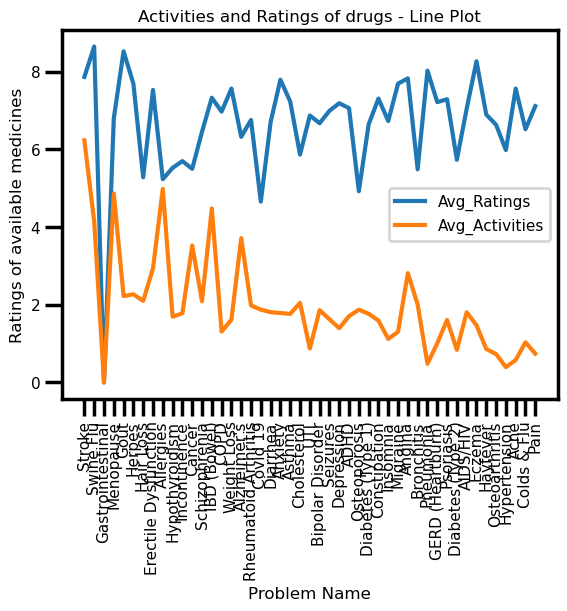

In [69]:
# Medical Conditions vs Ratings

avg_ratings = [0]*len(unique_medical_conditions)
avg_denominator = [0]*len(unique_medical_conditions)
avg_activities = [0]*len(unique_medical_conditions)
for i in range(len(unique_medical_conditions)):
    for j in data.index:
        if str(data["medical_condition"][j]) == unique_medical_conditions[i] and not np.isnan(data["rating"][j]):
            avg_ratings[i] += float(data["rating"][j])
            avg_denominator[i] += 1
            avg_activities[i] += float(data["activity"][j][:-1])

for i in range(len(unique_medical_conditions)):
    if avg_denominator[i] != 0:
        avg_ratings[i] = avg_ratings[i]/avg_denominator[i]
        avg_activities[i] = (avg_activities[i]/avg_denominator[i])/10

# for i in range(len(unique_medical_conditions)):
#     if avg_ratings[i]:
#         avg_ratings[i] = 0


plt.plot(unique_medical_conditions, np.array(avg_ratings))
plt.plot(unique_medical_conditions, np.array(avg_activities))
plt.xlabel(f"Problem Name")
plt.ylabel(f"Ratings of available medicines")
plt.title(f"Activities and Ratings of drugs - Line Plot")
plt.legend(["Avg_Ratings", "Avg_Activities"])
plt.xticks(rotation=90)
plt.show()

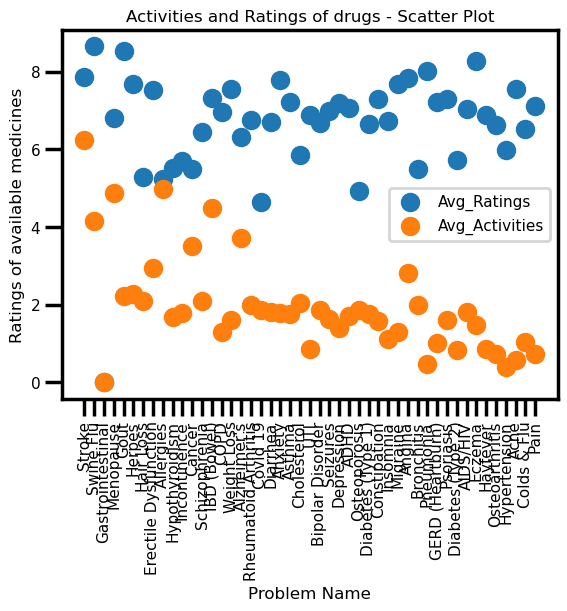

In [71]:
plt.scatter(unique_medical_conditions, np.array(avg_ratings))
plt.scatter(unique_medical_conditions, np.array(avg_activities))
plt.xlabel(f"Problem Name")
plt.ylabel(f"Ratings of available medicines")
plt.title(f"Activities and Ratings of drugs - Scatter Plot")
plt.legend(["Avg_Ratings", "Avg_Activities"])
plt.xticks(rotation=90)
plt.show()

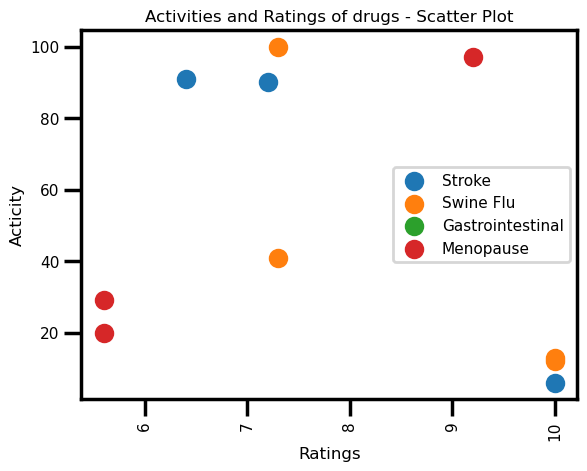

In [73]:
num = 4
diseases = unique_medical_conditions[:num]
property_chosen = [data["rating"], data["activity"]]

properties = []

for i in diseases:
    dataa = data.loc[data['medical_condition'] == i]
    rating = list(dataa["rating"])
    activity = []
    for j in dataa.index:
        activity.append(int(dataa["activity"][j][:-1]))
    plt.scatter(rating, activity)
    plt.xlabel(f"Ratings")
    plt.ylabel(f"Acticity")
    plt.title(f"Activities and Ratings of drugs - Scatter Plot")
    plt.legend(diseases)
    plt.xticks(rotation=90)

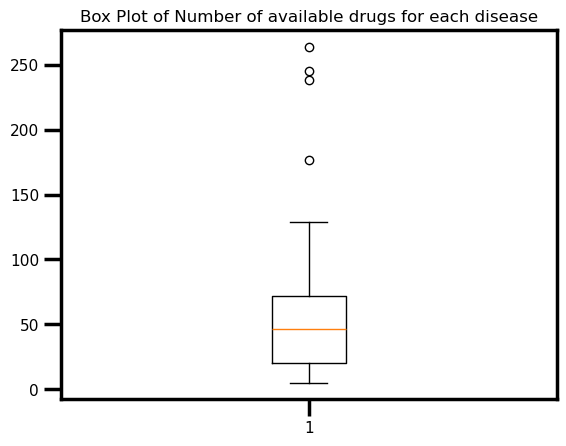

In [75]:
# available_drugs_for_condns
plt.boxplot(available_drugs_for_condns)
plt.title(f"Box Plot of Number of available drugs for each disease")
plt.show()

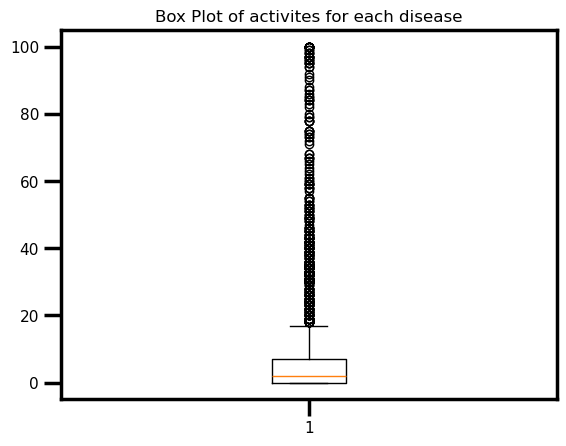

In [77]:
plt.boxplot(activities)
plt.title(f"Box Plot of activites for each disease")
plt.show()

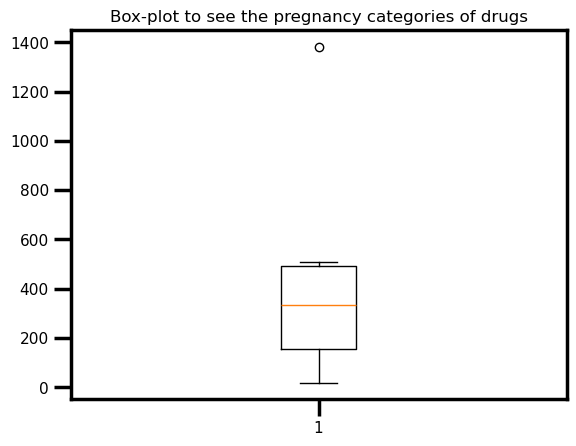

In [79]:
plt.boxplot(cnts_preg_cat)
plt.title(f"Box-plot to see the pregnancy categories of drugs")
plt.show()

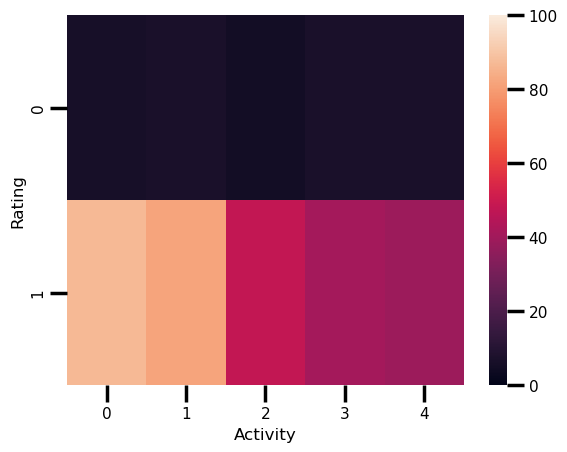

In [81]:
data = load_data()
activity = []
rating = []
for i in data.index:
    activity.append(int(data["activity"][i][:-1]))
    if not np.isnan(data["rating"][i]):
            rating.append(int(data["rating"][i]))
    else:
            rating.append(0)
num = 5
# correlation_matrix = np.corrcoef(activity[:num], rating[:num])
heatmap_sepal = sns.heatmap([rating[:num], activity[:num]], vmin = 0, vmax = 100)
plt.xlabel("Activity")
plt.ylabel("Rating")
plt.show()

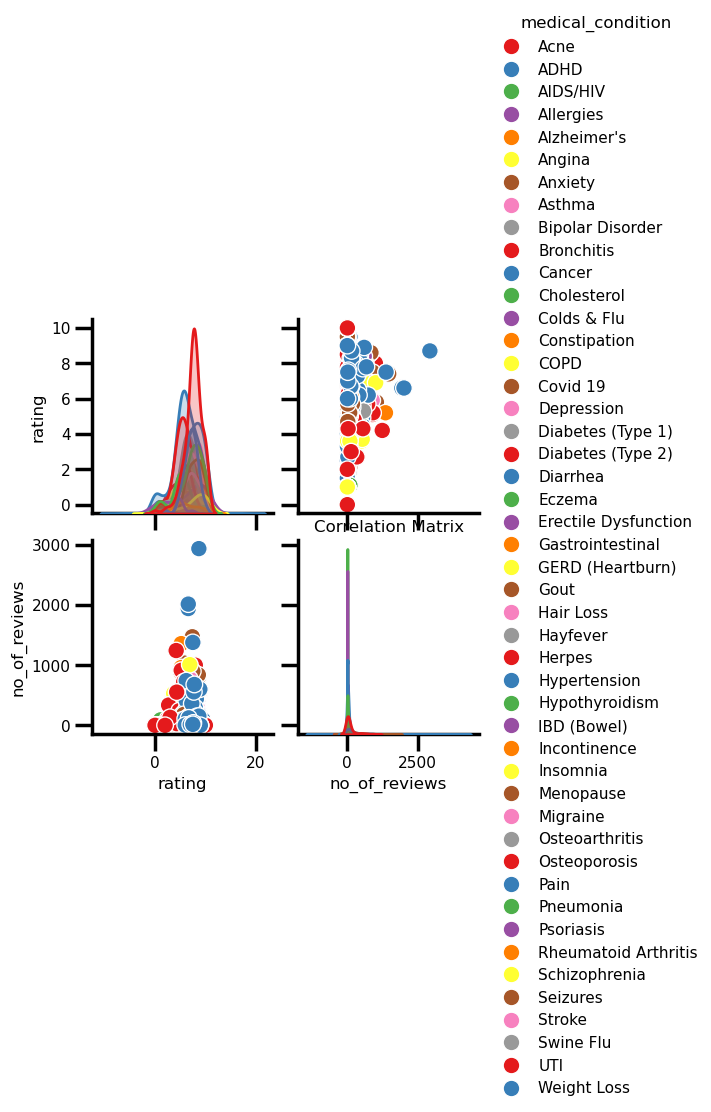

In [83]:
data = load_data()
df = data[["medical_condition", "rating", "no_of_reviews"]]
# df.drop(columns=df.columns[0], axis=1,  inplace=True)
sns.pairplot(df, kind="scatter", hue="medical_condition", palette="Set1")
plt.title("Correlation Matrix")
plt.show()